<div align="center">

# Loan Repayment Classification

### A reproducible comparison of four supervised-learning algorithms

**K-Nearest Neighbours · Decision Tree · Support Vector Machine · Logistic Regression**

</div>

---

## Executive summary

This notebook evaluates whether a historical loan will be classified as **paid off** or **in collection**. It converts an IBM course exercise into a transparent, reproducible model-comparison workflow with leakage-safe preprocessing, stratified cross-validation and an untouched external test set.

The purpose is educational: to demonstrate disciplined classification modelling and model evaluation on a small, imbalanced dataset. It is **not** a lending, credit-scoring or production decision system.

**Completed and analysed by Anupam Paul** as part of the IBM *Machine Learning with Python* coursework. The original instructional framework and datasets were provided by IBM.

## Business question and analytical objective

**Question:** Given basic loan and borrower attributes, how effectively can standard classification algorithms distinguish between loans that were paid off and loans that entered collection?

The analysis compares:

1. K-Nearest Neighbours (KNN)
2. Decision Tree
3. Support Vector Machine (SVM)
4. Logistic Regression

The primary model-selection measure is **macro F1**, which gives equal importance to both outcome classes. This is more informative than accuracy alone when the classes are imbalanced. Final performance is assessed once on a separate test dataset.

## Methodology

- Load the IBM training and external test datasets.
- Validate the schema and inspect class balance.
- Derive a weekend indicator from the loan effective date.
- Standardise numeric variables and one-hot encode categorical variables inside a scikit-learn pipeline.
- Tune each algorithm with five-fold stratified cross-validation using macro F1.
- Evaluate the fitted models on the untouched external test set.
- Compare accuracy, balanced accuracy, macro F1, weighted F1, Jaccard score, ROC-AUC and log loss.

All preprocessing is fitted **only on training folds**. This prevents information from validation or test observations leaking into model training.

## 1. Environment and imports

Required packages: <code>pandas</code>, <code>numpy</code>, <code>matplotlib</code> and <code>scikit-learn</code>.

In [1]:
from pathlib import Path
from urllib.error import URLError

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    jaccard_score,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

pandas: 2.2.3
scikit-learn: 1.8.0


## 2. Data acquisition

The training dataset contains historical labelled observations used for cross-validation and fitting. The second dataset is held back for final evaluation.

In [2]:
TRAIN_URL = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/"
    "FinalModule_Coursera/data/loan_train.csv"
)
TEST_URL = (
    "https://s3-api.us-geo.objectstorage.softlayer.net/"
    "cf-courses-data/CognitiveClass/ML0101ENv3/labs/loan_test.csv"
)

def load_dataset(url, local_fallback):
    try:
        return pd.read_csv(url)
    except (URLError, OSError):
        path = Path(local_fallback)
        if not path.exists():
            raise
        return pd.read_csv(path)

train_raw = load_dataset(TRAIN_URL, "data/loan_train.csv")
test_raw = load_dataset(TEST_URL, "data/loan_test.csv")

print(f"Training data: {train_raw.shape[0]} rows × {train_raw.shape[1]} columns")
print(f"External test data: {test_raw.shape[0]} rows × {test_raw.shape[1]} columns")

Training data: 346 rows × 10 columns
External test data: 54 rows × 10 columns


### Data dictionary

| Variable | Description |
|---|---|
| <code>loan_status</code> | Target outcome: <code>PAIDOFF</code> or <code>COLLECTION</code> |
| <code>Principal</code> | Original loan principal |
| <code>terms</code> | Repayment term in days |
| <code>effective_date</code> | Loan origination date |
| <code>due_date</code> | Scheduled repayment date |
| <code>age</code> | Borrower age |
| <code>education</code> | Reported education category |
| <code>Gender</code> | Reported gender category |

In [3]:
def clean_columns(frame):
    cleaned = frame.copy()
    return cleaned.loc[:, ~cleaned.columns.astype(str).str.startswith("Unnamed")]

train_raw = clean_columns(train_raw)
test_raw = clean_columns(test_raw)

required_columns = {
    "loan_status", "Principal", "terms", "effective_date",
    "due_date", "age", "education", "Gender"
}

for dataset_name, frame in {"training": train_raw, "test": test_raw}.items():
    missing = required_columns.difference(frame.columns)
    if missing:
        raise ValueError(f"{dataset_name.title()} data is missing columns: {sorted(missing)}")

quality_summary = pd.DataFrame(
    {
        "Training": [
            len(train_raw),
            train_raw.duplicated().sum(),
            train_raw.isna().sum().sum(),
        ],
        "External test": [
            len(test_raw),
            test_raw.duplicated().sum(),
            test_raw.isna().sum().sum(),
        ],
    },
    index=["Rows", "Duplicate rows", "Missing values"],
)
quality_summary

,Training,External test
Rows,346,54
Duplicate rows,40,2
Missing values,0,0


## 3. Exploratory analysis

The outcome distribution is inspected before modelling because class imbalance affects how performance should be interpreted.

,Count,Share (%)
loan_status,,
PAIDOFF,260,75.1000
COLLECTION,86,24.9000


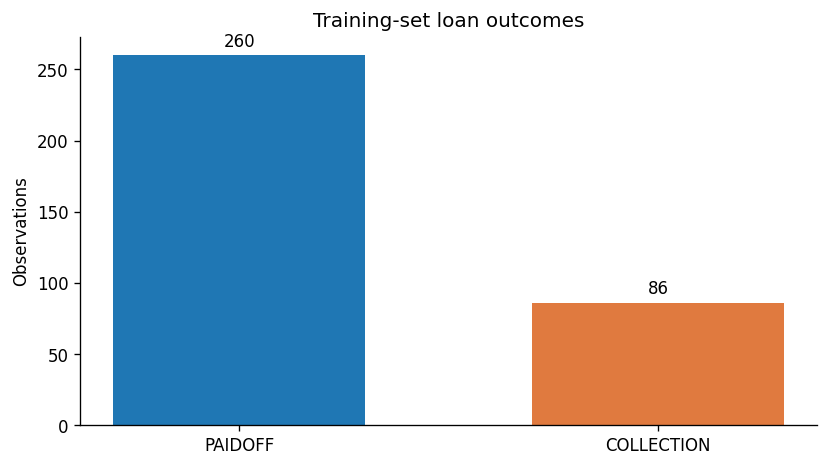

In [4]:
class_counts = train_raw["loan_status"].value_counts().reindex(["PAIDOFF", "COLLECTION"])
class_share = (class_counts / class_counts.sum() * 100).round(1)

class_summary = pd.DataFrame({"Count": class_counts, "Share (%)": class_share})
display(class_summary)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    class_summary.index,
    class_summary["Count"],
    color=["#1F77B4", "#E07A3F"],
    width=0.6,
)
ax.bar_label(bars, padding=3)
ax.set_title("Training-set loan outcomes")
ax.set_ylabel("Observations")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The training data is weighted towards paid-off loans. Consequently, the analysis reports **macro F1** and **balanced accuracy** alongside conventional accuracy and weighted metrics.

## 4. Feature engineering

The original project observed that repayment outcomes varied by the day on which a loan became effective. A binary <code>weekend</code> feature is therefore derived from <code>effective_date</code>.

The model uses four numeric features—principal, term, age and weekend—and two categorical features—education and gender.

In [5]:
def create_features(frame):
    data = frame.copy()
    data["effective_date"] = pd.to_datetime(data["effective_date"], errors="coerce")
    data["weekend"] = (data["effective_date"].dt.dayofweek > 3).astype("int64")
    return data[
        ["Principal", "terms", "age", "weekend", "education", "Gender"]
    ]

X_train = create_features(train_raw)
y_train = train_raw["loan_status"].copy()
X_test = create_features(test_raw)
y_test = test_raw["loan_status"].copy()

print(f"Model-development observations: {len(X_train)}")
print(f"Untouched external-test observations: {len(X_test)}")
display(X_train.head())

Model-development observations: 346
Untouched external-test observations: 54


,Principal,terms,age,weekend,education,Gender
0,1000,30,45,0,High School or Below,male
1,1000,30,33,0,Bechalor,female
2,1000,15,27,0,college,male
3,1000,30,28,1,college,female
4,1000,30,29,1,college,male


## 5. Leakage-safe preprocessing and model tuning

Numeric imputation and scaling, together with categorical imputation and one-hot encoding, are contained inside each model pipeline. During cross-validation, every transformer is fitted only on the relevant training fold.

In [6]:
numeric_features = ["Principal", "terms", "age", "weekend"]
categorical_features = ["education", "Gender"]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model_specs = {
    "KNN": {
        "estimator": KNeighborsClassifier(),
        "parameters": {
            "model__n_neighbors": [3, 5, 7, 9, 11, 13],
            "model__weights": ["uniform", "distance"],
        },
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "parameters": {
            "model__max_depth": [3, 4, 5, 6, None],
            "model__min_samples_leaf": [1, 3, 5, 10],
            "model__class_weight": [None, "balanced"],
        },
    },
    "SVM": {
        "estimator": SVC(
            kernel="rbf",
            probability=True,
            random_state=RANDOM_STATE,
        ),
        "parameters": {
            "model__C": [0.1, 1, 10],
            "model__gamma": ["scale", "auto"],
            "model__class_weight": [None, "balanced"],
        },
    },
    "Logistic Regression": {
        "estimator": LogisticRegression(
            solver="liblinear",
            max_iter=2_000,
            random_state=RANDOM_STATE,
        ),
        "parameters": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__class_weight": [None, "balanced"],
        },
    },
}

In [7]:
searches = {}
cv_rows = []

for model_name, spec in model_specs.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", spec["estimator"]),
        ]
    )
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=spec["parameters"],
        scoring="f1_macro",
        cv=cv,
        n_jobs=1,
        refit=True,
    )
    search.fit(X_train, y_train)
    searches[model_name] = search
    cv_rows.append(
        {
            "Model": model_name,
            "CV macro F1": search.best_score_,
            "Best parameters": str(
                {key.replace("model__", ""): value for key, value in search.best_params_.items()}
            ),
        }
    )

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values("CV macro F1", ascending=False)
    .reset_index(drop=True)
)
cv_results

,Model,CV macro F1,Best parameters
0,Decision Tree,0.6549,"{'class_weight': 'balanced', 'max_depth': 5, '..."
1,Logistic Regression,0.6418,"{'C': 10, 'class_weight': 'balanced'}"
2,SVM,0.6338,"{'C': 0.1, 'class_weight': 'balanced', 'gamma'..."
3,KNN,0.5984,"{'n_neighbors': 5, 'weights': 'distance'}"


## 6. External test-set evaluation

The external test dataset has not been used for preprocessing, tuning or model selection. It is now used once to estimate out-of-sample performance.

In [8]:
test_rows = []
predictions = {}

for model_name, search in searches.items():
    estimator = search.best_estimator_
    predicted = estimator.predict(X_test)
    probabilities = estimator.predict_proba(X_test)
    model_classes = list(estimator.named_steps["model"].classes_)
    collection_probability = probabilities[:, model_classes.index("COLLECTION")]

    predictions[model_name] = predicted
    test_rows.append(
        {
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, predicted),
            "Balanced accuracy": balanced_accuracy_score(y_test, predicted),
            "Macro F1": f1_score(y_test, predicted, average="macro"),
            "Weighted F1": f1_score(y_test, predicted, average="weighted"),
            "Weighted Jaccard": jaccard_score(y_test, predicted, average="weighted"),
            "ROC-AUC": roc_auc_score(
                (y_test == "COLLECTION").astype(int),
                collection_probability,
            ),
            "Log loss": log_loss(y_test, probabilities, labels=model_classes),
        }
    )

test_results = (
    pd.DataFrame(test_rows)
    .sort_values("Macro F1", ascending=False)
    .reset_index(drop=True)
)
test_results.round(3)

,Model,Accuracy,Balanced accuracy,Macro F1,Weighted F1,Weighted Jaccard,ROC-AUC,Log loss
0,Decision Tree,0.7220,0.7430,0.6920,0.7380,0.5920,0.7730,1.7360
1,KNN,0.7220,0.6270,0.6300,0.7190,0.5830,0.6100,4.9200
2,SVM,0.6300,0.7270,0.6210,0.6480,0.4820,0.7520,0.4710
3,Logistic Regression,0.5930,0.6550,0.5780,0.6160,0.4480,0.7590,0.5650


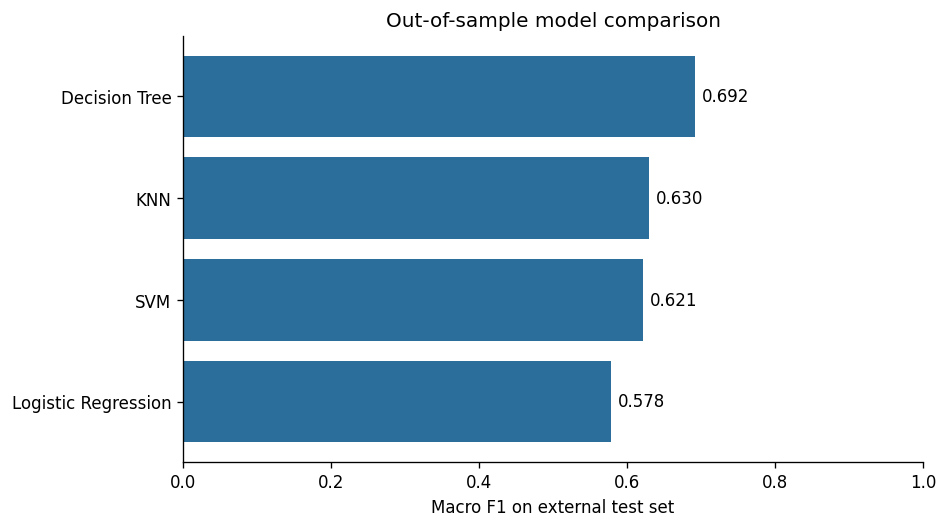

In [9]:
plot_data = test_results.sort_values("Macro F1")

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(plot_data["Model"], plot_data["Macro F1"], color="#2C6E9B")
ax.bar_label(bars, fmt="%.3f", padding=4)
ax.set_xlim(0, 1)
ax.set_xlabel("Macro F1 on external test set")
ax.set_title("Out-of-sample model comparison")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Confusion matrices

Each matrix shows where the models correctly or incorrectly classified paid-off and collection outcomes. Minority-class performance should be considered alongside the overall scores.

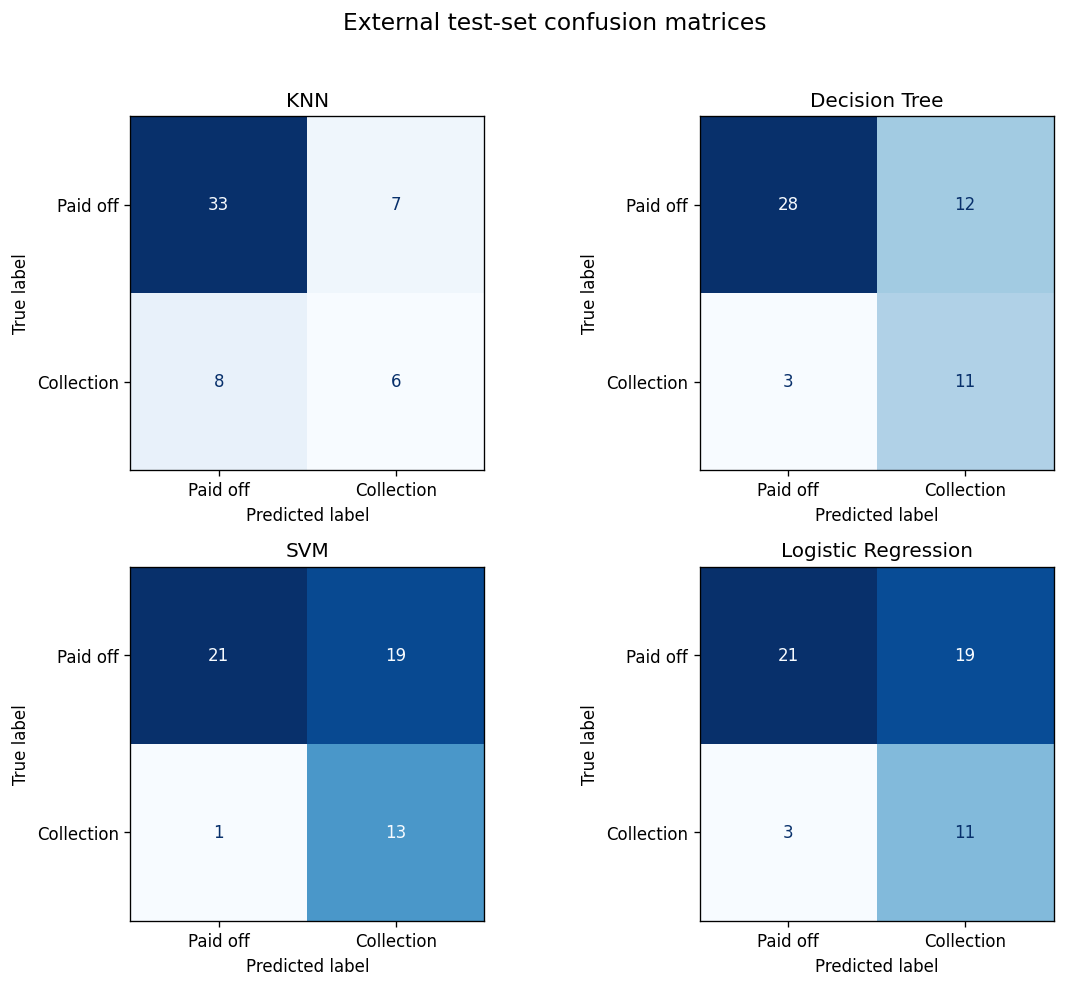

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, model_name in zip(axes.ravel(), model_specs):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[model_name],
        labels=["PAIDOFF", "COLLECTION"],
        display_labels=["Paid off", "Collection"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(model_name)

fig.suptitle("External test-set confusion matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Cross-validation recommendation and detailed test performance

The recommended model is selected from cross-validation results—not from the external test table. This preserves the role of the test data as an independent final check.

In [11]:
recommended_model = cv_results.loc[0, "Model"]
recommended_search = searches[recommended_model]
recommended_prediction = predictions[recommended_model]
recommended_test_row = test_results.set_index("Model").loc[recommended_model]

print(f"Cross-validation recommendation: {recommended_model}")
print(f"Mean CV macro F1: {recommended_search.best_score_:.3f}")
print(f"External-test macro F1: {recommended_test_row['Macro F1']:.3f}")
print(f"External-test balanced accuracy: {recommended_test_row['Balanced accuracy']:.3f}")
print("\nExternal-test classification report:\n")
print(classification_report(y_test, recommended_prediction, digits=3))

Cross-validation recommendation: Decision Tree
Mean CV macro F1: 0.655
External-test macro F1: 0.692
External-test balanced accuracy: 0.743

External-test classification report:

              precision    recall  f1-score   support

  COLLECTION      0.478     0.786     0.595        14
     PAIDOFF      0.903     0.700     0.789        40

    accuracy                          0.722        54
   macro avg      0.691     0.743     0.692        54
weighted avg      0.793     0.722     0.738        54



## 7. Interpretation

- Cross-validation provides the basis for model selection, while the independent test set provides the final performance estimate.
- Macro F1 and balanced accuracy are emphasised because the collection class is materially smaller than the paid-off class.
- Any gap between cross-validation and external-test performance is expected to be more volatile with a small dataset.
- The comparatively high log loss for some models indicates overconfident probability estimates; probability calibration would be required before interpreting the scores as risk probabilities.
- The analysis demonstrates comparative modelling technique; it does not establish that the available variables are sufficient for responsible lending decisions.

For a production credit-risk setting, performance would need to be validated on a much larger and more representative population, across time periods and relevant customer segments.

## 8. Limitations and responsible-use considerations

1. **Small sample:** The training and test datasets are too small for production inference.
2. **Limited variables:** Income, debt burden, employment stability, repayment history and other potentially important factors are unavailable.
3. **Class imbalance:** Collection cases are less common, increasing uncertainty around minority-class performance.
4. **Temporal validation:** The data does not support a robust out-of-time validation design.
5. **Fairness:** Gender and education are included because they formed part of the original coursework. In a real lending system, protected or sensitive attributes require legal, ethical and fairness review and may be inappropriate as predictive inputs.
6. **Decision scope:** Model outputs must not be used as automated lending decisions.

## 9. Potential enhancements

- Compare repeated stratified cross-validation results with confidence intervals.
- Add probability calibration and threshold analysis based on the cost of false negatives and false positives.
- Examine precision-recall curves for the collection class.
- Test class-weighted and resampling strategies more systematically.
- Evaluate model stability across demographic and temporal segments.
- Add explainability analysis using permutation importance or SHAP.
- Package preprocessing and inference as a versioned, testable pipeline.

## Attribution

This notebook is a revised portfolio presentation of coursework completed for IBM's *Machine Learning with Python* programme.

- **Implementation, analysis and portfolio revision:** [Anupam Paul](https://github.com/anupamctg)
- **Professional profile:** [LinkedIn](https://www.linkedin.com/in/anupam-paul/)
- **Portfolio:** [anupampaul.page](https://www.anupampaul.page/)
- **Original instructional framework and datasets:** IBM Skills Network / Cognitive Class

The IBM attribution is retained to distinguish the supplied learning framework and data from the learner's implementation and subsequent methodological revisions.